In [1]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt

from src.concaves.log import LogConcave

from src.diffeomorphisms.composition import CompositionDiffeomorphism
from src.diffeomorphisms.vector.concave import ConcaveVectorDiffeomorphism
from src.diffeomorphisms.vector.starflow import StarFlowVectorDiffeomorphism
from src.diffeomorphisms.vector.transform import TransformVectorDiffeomorphism

from src.distributions.starflows.r2.river_cross import RiverCrossStarFlowDistribution

from src.manifolds.euclidean.vector.pullback.standard import StandardPullbackVectorEuclidean
from src.manifolds.isometrized_euclidean.vector import l2IsometrizedVectorEuclidean

from src.riemannian_neural_networks.archetypal_mappings.exact import ExactRiemannianArchetypalMapping
from src.riemannian_neural_networks.archetypal_mappings.relaxed import RelaxedRiemannianArchetypalMapping

# results folder
results_folder = os.path.join("results", "river_cross")
os.makedirs(results_folder, exist_ok=True)

# change font size of all plots
plt.rcParams.update({'font.size': 16})
markers = ['^', 'X', 'd', '*']

# set random seed
torch.manual_seed(31)
np.random.seed(31)

In [2]:
star_flow = RiverCrossStarFlowDistribution()

/Users/wdiepeveen/Documents/Postdoc/projects/6 - Lyme Geometry/src/Riemannian-Archetypal-Analysis/.venv/lib/python3.13/site-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /Users/runner/work/pytorch/pytorch/aten/src/ATen/native/TensorShape.cpp:4384.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


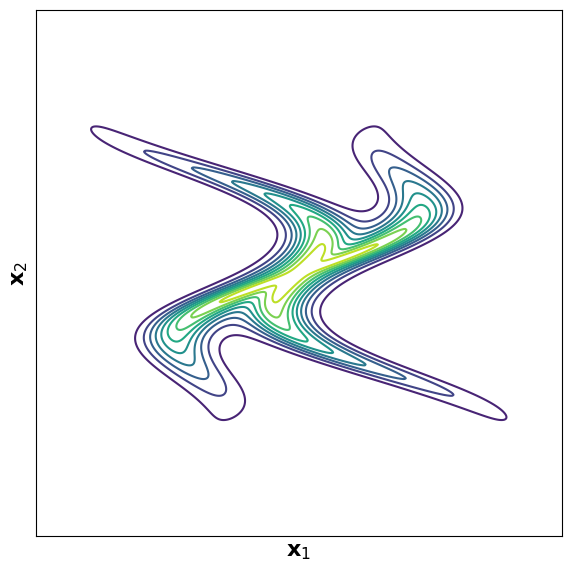

In [3]:
n_points = 1001
x = torch.linspace(-7, 7, n_points)
y = torch.linspace(-7, 7, n_points)
X, Y = torch.meshgrid(x, y)
XY = torch.stack([X.flatten(), Y.flatten()], dim=-1)
log_probs_multi = torch.exp(star_flow.log_prob(XY).reshape(n_points, n_points).detach())


# plot samples
plt.figure(figsize=(6, 6))
plt.contour(X.numpy(), Y.numpy(), log_probs_multi.numpy(), levels=10, cmap='viridis')
plt.xlabel(r'$\mathbf{x}_1$')
plt.ylabel(r'$\mathbf{x}_2$')
plt.xlim(-4, 4)
plt.ylim(-4, 4)
plt.xticks([])
plt.yticks([])
plt.tight_layout()
plt.savefig(os.path.join(results_folder, "log_probs.png"))
plt.show()

In [4]:
phi = TransformVectorDiffeomorphism(2, star_flow._transform)
phi_chi = StarFlowVectorDiffeomorphism(2, star_flow)
psi = ConcaveVectorDiffeomorphism(2, LogConcave(a=10.))
Omega = CompositionDiffeomorphism([phi_chi, psi])

# pullback manifolds
phi_manifold = StandardPullbackVectorEuclidean(phi)
phi_chi_manifold = StandardPullbackVectorEuclidean(phi_chi)
Omega_manifold = StandardPullbackVectorEuclidean(Omega)

# iso pullback manifolds
iso_phi_manifold = l2IsometrizedVectorEuclidean(phi_manifold, num_intervals=20)
iso_phi_chi_manifold = l2IsometrizedVectorEuclidean(phi_chi_manifold, num_intervals=20)
iso_Omega_manifold = l2IsometrizedVectorEuclidean(Omega_manifold, num_intervals=20)

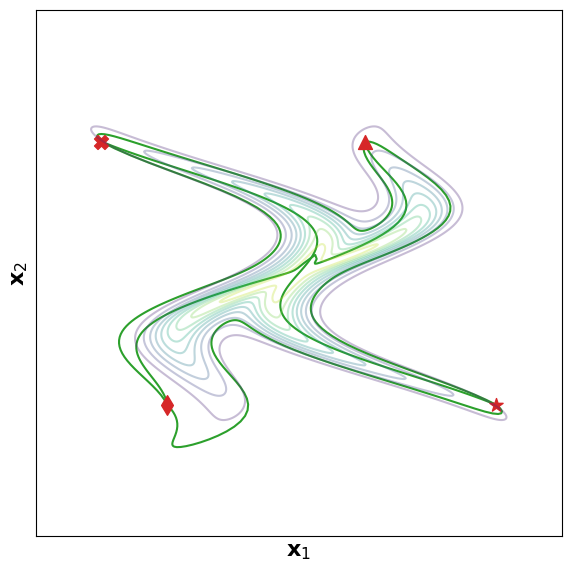

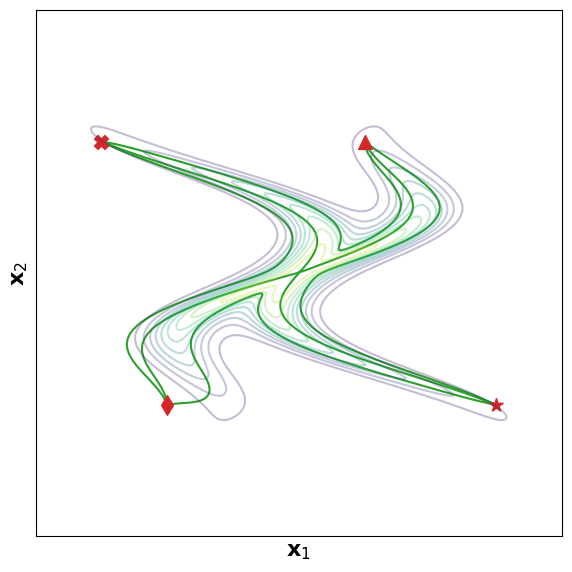

In [5]:
# plot geodesics
t = torch.linspace(0, 1, 101)
archetypes = torch.tensor([[1., 2.], [-3., 2.], [-2., -2.], [3., -2.]])

plt.figure(figsize=(6,6))
plt.contour(X.numpy(), Y.numpy(), log_probs_multi.numpy(), levels=10, cmap='viridis', alpha=0.3)
for i in range(4):
    for j in range(i+1, 4):
        x_i = archetypes[i]
        x_j = archetypes[j]
        # interpolate between cluster centers
        phi_chi_geodesics = phi_chi_manifold.geodesic(x_i[None,None], x_j[None,None], t)[0,0,0]
        plt.plot(phi_chi_geodesics[:, 0].numpy(), phi_chi_geodesics[:, 1].numpy(), color=plt.cm.tab10(2), zorder=0)
    plt.scatter(archetypes[i, 0].numpy(), archetypes[i, 1].numpy(), color=plt.cm.tab10(3), marker=markers[i], s=100, zorder=1)
plt.xlabel(r'$\mathbf{x}_1$')
plt.ylabel(r'$\mathbf{x}_2$')
plt.xlim(-4, 4)
plt.ylim(-4, 4)
plt.xticks([])
plt.yticks([])
plt.tight_layout()
plt.savefig(os.path.join(results_folder, "geodesics_phi_chi_curves.png"))
plt.show()

plt.figure(figsize=(6,6))
plt.contour(X.numpy(), Y.numpy(), log_probs_multi.numpy(), levels=10, cmap='viridis', alpha=0.3)
for i in range(4):
    for j in range(i+1, 4):
        mu_i = archetypes[i]
        mu_j = archetypes[j]
        # interpolate between cluster centers
        Omega_geodesics = Omega_manifold.geodesic(mu_i[None,None], mu_j[None,None], t)[0,0,0]
        plt.plot(Omega_geodesics[:, 0].numpy(), Omega_geodesics[:, 1].numpy(), color=plt.cm.tab10(2), zorder=0)
    plt.scatter(archetypes[i, 0].numpy(), archetypes[i, 1].numpy(), color=plt.cm.tab10(3), marker=markers[i], s=100, zorder=1)
plt.xlabel(r'$\mathbf{x}_1$')
plt.ylabel(r'$\mathbf{x}_2$')
plt.xlim(-4, 4)
plt.ylim(-4, 4)
plt.xticks([])
plt.yticks([])
plt.tight_layout()
plt.savefig(os.path.join(results_folder, "geodesics_Omega_curves.png"))
plt.show()

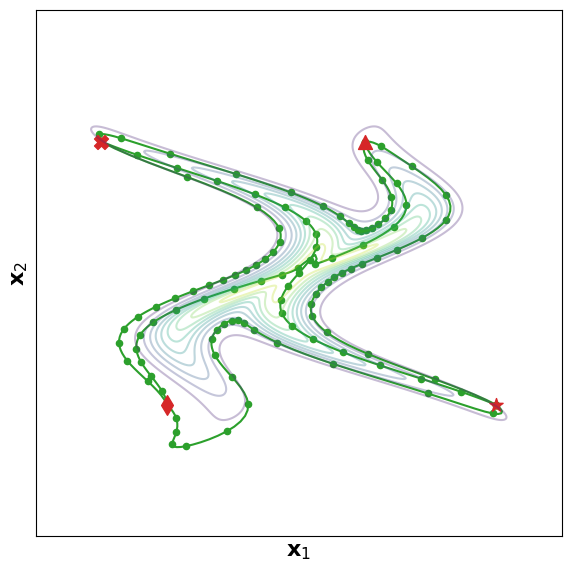

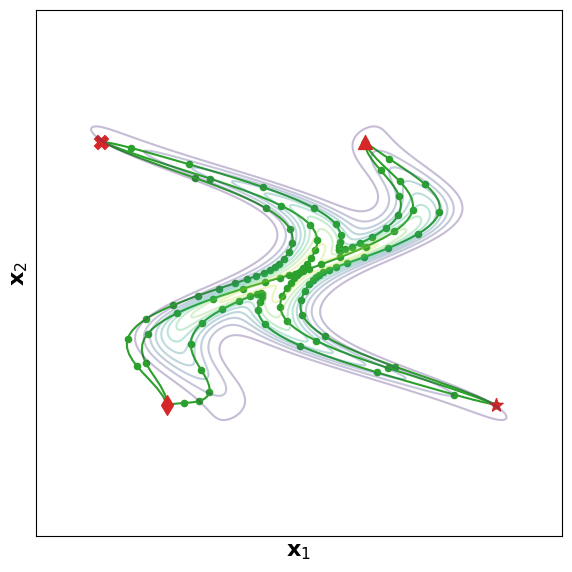

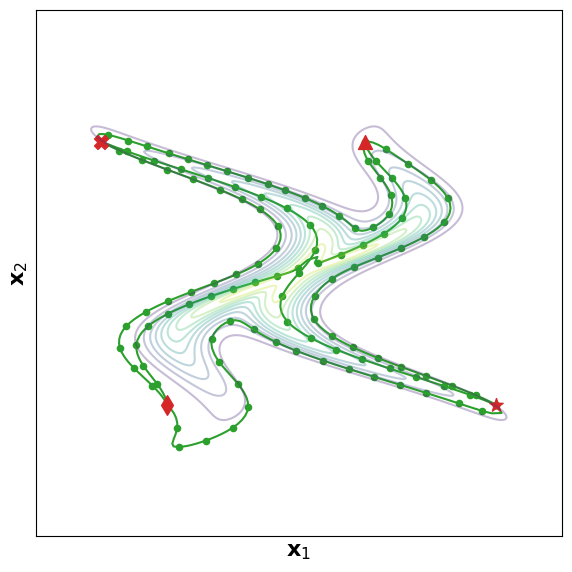

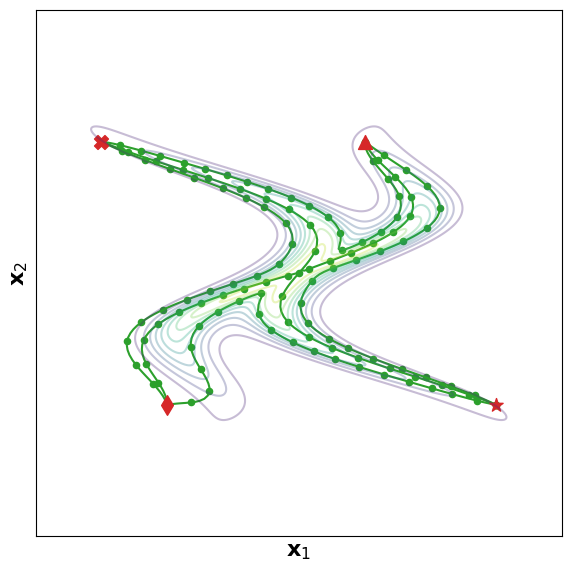

In [6]:
# plot geodesics with closer look at interpolation points
t = torch.linspace(0, 1, 101)
T = 5
archetypes = torch.tensor([[1., 2.], [-3., 2.], [-2., -2.], [3., -2.]])

plt.figure(figsize=(6,6))
plt.contour(X.numpy(), Y.numpy(), log_probs_multi.numpy(), levels=10, cmap='viridis', alpha=0.3)

for i in range(4):
    for j in range(i+1, 4):
        x_i = archetypes[i]
        x_j = archetypes[j]
        # interpolate between cluster centers
        phi_chi_geodesics = phi_chi_manifold.geodesic(x_i[None,None], x_j[None,None], t)[0,0,0]
        plt.plot(phi_chi_geodesics[:, 0].numpy(), phi_chi_geodesics[:, 1].numpy(), color=plt.cm.tab10(2), zorder=0)
        plt.scatter(phi_chi_geodesics[::T, 0].numpy(), phi_chi_geodesics[::T, 1].numpy(), color=plt.cm.tab10(2), marker='o', s=20, zorder=0)

    plt.scatter(archetypes[i, 0].numpy(), archetypes[i, 1].numpy(), color=plt.cm.tab10(3), marker=markers[i], s=100, zorder=1)
    
plt.xlabel(r'$\mathbf{x}_1$')
plt.ylabel(r'$\mathbf{x}_2$')
plt.xlim(-4, 4)
plt.ylim(-4, 4)
plt.xticks([])
plt.yticks([])
plt.tight_layout()
plt.savefig(os.path.join(results_folder, "geodesics_phi_chi.png"))
plt.show()

plt.figure(figsize=(6,6))
plt.contour(X.numpy(), Y.numpy(), log_probs_multi.numpy(), levels=10, cmap='viridis', alpha=0.3)

for i in range(4):
    for j in range(i+1, 4):
        mu_i = archetypes[i]
        mu_j = archetypes[j]
        # interpolate between cluster centers
        Omega_geodesics = Omega_manifold.geodesic(mu_i[None,None], mu_j[None,None], t)[0,0,0]
        plt.plot(Omega_geodesics[:, 0].numpy(), Omega_geodesics[:, 1].numpy(), color=plt.cm.tab10(2), zorder=0)
        plt.scatter(Omega_geodesics[::T, 0].numpy(), Omega_geodesics[::T, 1].numpy(), color=plt.cm.tab10(2), marker='o', s=20, zorder=0)

    plt.scatter(archetypes[i, 0].numpy(), archetypes[i, 1].numpy(), color=plt.cm.tab10(3), marker=markers[i], s=100, zorder=1)
plt.xlabel(r'$\mathbf{x}_1$')
plt.ylabel(r'$\mathbf{x}_2$')
plt.xlim(-4, 4)
plt.ylim(-4, 4)
plt.xticks([])
plt.yticks([])
plt.tight_layout()
plt.savefig(os.path.join(results_folder, "geodesics_Omega.png"))
plt.show()

# iso pullback manifolds
plt.figure(figsize=(6,6))
plt.contour(X.numpy(), Y.numpy(), log_probs_multi.numpy(), levels=10, cmap='viridis', alpha=0.3)

for i in range(4):
    for j in range(i+1, 4):
        x_i = archetypes[i]
        x_j = archetypes[j]
        # interpolate between cluster centers
        phi_chi_geodesics = iso_phi_chi_manifold.geodesic(x_i[None,None], x_j[None,None], t)[0,0,0]
        plt.plot(phi_chi_geodesics[:, 0].numpy(), phi_chi_geodesics[:, 1].numpy(), color=plt.cm.tab10(2), zorder=0)
        plt.scatter(phi_chi_geodesics[::T, 0].numpy(), phi_chi_geodesics[::T, 1].numpy(), color=plt.cm.tab10(2), marker='o', s=20, zorder=0)

    plt.scatter(archetypes[i, 0].numpy(), archetypes[i, 1].numpy(), color=plt.cm.tab10(3), marker=markers[i], s=100, zorder=1)
plt.xlabel(r'$\mathbf{x}_1$')
plt.ylabel(r'$\mathbf{x}_2$')
plt.xlim(-4, 4)
plt.ylim(-4, 4)
plt.xticks([])
plt.yticks([])
plt.tight_layout()
plt.savefig(os.path.join(results_folder, "geodesics_phi_chi_iso.png"))
plt.show()

plt.figure(figsize=(6,6))
plt.contour(X.numpy(), Y.numpy(), log_probs_multi.numpy(), levels=10, cmap='viridis', alpha=0.3)

for i in range(4):
    for j in range(i+1, 4):
        mu_i = archetypes[i]
        mu_j = archetypes[j]
        # interpolate between cluster centers
        Omega_geodesics = iso_Omega_manifold.geodesic(mu_i[None,None], mu_j[None,None], t)[0,0,0]
        plt.plot(Omega_geodesics[:, 0].numpy(), Omega_geodesics[:, 1].numpy(), color=plt.cm.tab10(2), zorder=0)
        plt.scatter(Omega_geodesics[::T, 0].numpy(), Omega_geodesics[::T, 1].numpy(), color=plt.cm.tab10(2), marker='o', s=20, zorder=0)

    plt.scatter(archetypes[i, 0].numpy(), archetypes[i, 1].numpy(), color=plt.cm.tab10(3), marker=markers[i], s=100, zorder=1)
plt.xlabel(r'$\mathbf{x}_1$')
plt.ylabel(r'$\mathbf{x}_2$')
plt.xlim(-4, 4)
plt.ylim(-4, 4)
plt.xticks([])
plt.yticks([])
plt.tight_layout()
plt.savefig(os.path.join(results_folder, "geodesics_Omega_iso.png"))
plt.show()

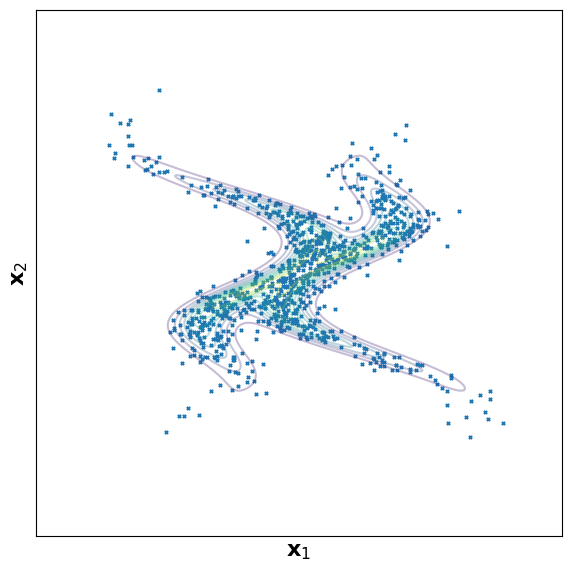

In [7]:
data = star_flow.sample(1000)

# plot samples
plt.figure(figsize=(6, 6))
plt.contour(X.numpy(), Y.numpy(), log_probs_multi.numpy(), levels=10, cmap='viridis', alpha=0.3)
plt.scatter(data[:, 0].numpy(), data[:, 1].numpy(), color=plt.cm.tab10(0), marker='x', s=5)
plt.xlabel(r'$\mathbf{x}_1$')
plt.ylabel(r'$\mathbf{x}_2$')
plt.xlim(-5, 5)
plt.ylim(-5, 5)
plt.xticks([])
plt.yticks([])
plt.tight_layout()
plt.savefig(os.path.join(results_folder, "samples_starflow.png"))
plt.show()

In [8]:
# construct RAM
relaxed_Omega_ram = RelaxedRiemannianArchetypalMapping(Omega_manifold, archetypes)
exact_Omega_ram = ExactRiemannianArchetypalMapping(Omega_manifold, archetypes)

Iteration 19 Convergence achieved with diff 7.99e-04. Stopping optimization.
Iteration 19 Convergence achieved with diff 7.99e-04. Stopping optimization.
Iteration 124 Convergence achieved with diff 8.02e-04. Stopping optimization.


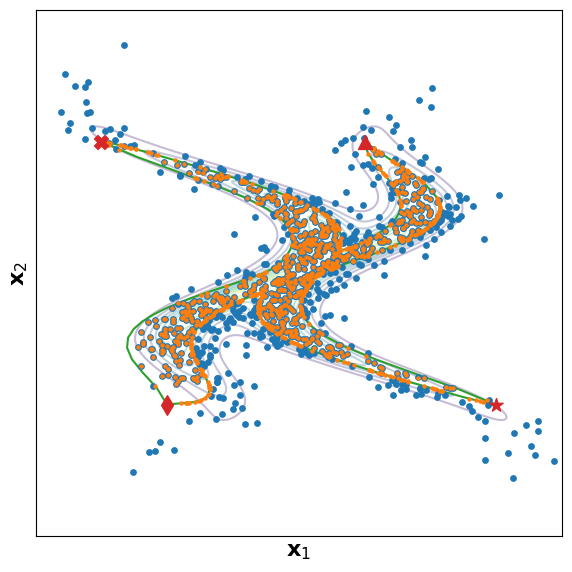

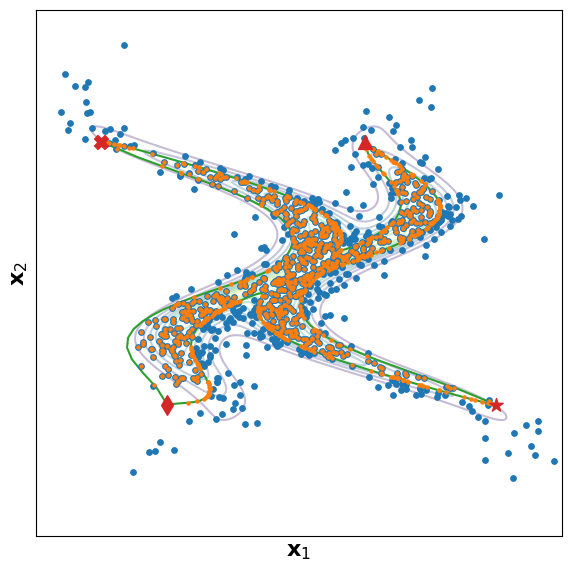

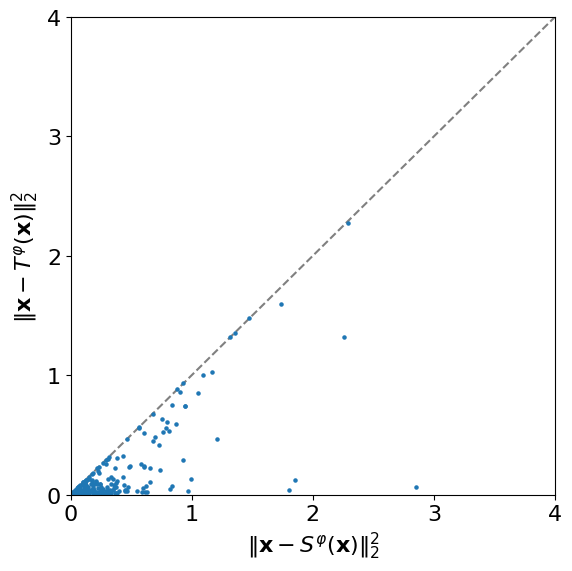

In [9]:
with torch.no_grad():
    # project data
    relaxed_Omega_ram_projected_data = relaxed_Omega_ram.forward(data)
    exact_Omega_ram_projected_data = exact_Omega_ram.forward(data)

    # compute enclosing geodesics
    Omega_geodesics = torch.zeros(4, 50, 2)
    t = torch.linspace(0, 1, 50)
    for i in range(4):
        Omega_geodesics[i] = Omega_manifold.geodesic(archetypes[i][None,None], archetypes[(i+1)%4][None,None], t)[0,0]

relaxed_errors_Omega_ram = torch.norm(relaxed_Omega_ram_projected_data - data, dim=-1)**2
exact_errors_Omega_ram = torch.norm(exact_Omega_ram_projected_data - data, dim=-1)**2

# plot projected data
plt.figure(figsize=(6, 6))
plt.contour(X.numpy(), Y.numpy(), log_probs_multi.numpy(), levels=10, cmap='viridis', alpha=0.3, zorder=0)
for i in range(4):
    plt.plot(Omega_geodesics[i,:,0].numpy(), Omega_geodesics[i,:,1].numpy(), color=plt.cm.tab10(2), zorder=1)
plt.scatter(data[:, 0].numpy(), data[:, 1].numpy(), color=plt.cm.tab10(0), marker='o', s=15, zorder=2)
plt.scatter(relaxed_Omega_ram_projected_data[:, 0].numpy(), relaxed_Omega_ram_projected_data[:, 1].numpy(), color=plt.cm.tab10(1), marker='o', s=5, zorder=2)
for i in range(4):
    plt.scatter(archetypes[i, 0].numpy(), archetypes[i, 1].numpy(), color=plt.cm.tab10(3), marker=markers[i], s=100, zorder=3)
plt.xlabel(r'$\mathbf{x}_1$')
plt.ylabel(r'$\mathbf{x}_2$')
plt.xlim(-4, 4)
plt.ylim(-4, 4)
plt.xticks([])
plt.yticks([])
plt.tight_layout()
plt.savefig(os.path.join(results_folder, "samples_ram_projected_relaxed_Omega.png"))
plt.show()


# plot projected data
plt.figure(figsize=(6, 6))
plt.contour(X.numpy(), Y.numpy(), log_probs_multi.numpy(), levels=10, cmap='viridis', alpha=0.3, zorder=0)
for i in range(4):
    plt.plot(Omega_geodesics[i,:,0].numpy(), Omega_geodesics[i,:,1].numpy(), color=plt.cm.tab10(2), zorder=1)
plt.scatter(data[:, 0].numpy(), data[:, 1].numpy(), color=plt.cm.tab10(0), marker='o', s=15, zorder=2)
plt.scatter(exact_Omega_ram_projected_data[:, 0].numpy(), exact_Omega_ram_projected_data[:, 1].numpy(), color=plt.cm.tab10(1), marker='o', s=5, zorder=2)
for i in range(4):
    plt.scatter(archetypes[i, 0].numpy(), archetypes[i, 1].numpy(), color=plt.cm.tab10(3), marker=markers[i], s=100, zorder=3)
plt.xlabel(r'$\mathbf{x}_1$')
plt.ylabel(r'$\mathbf{x}_2$')
plt.xlim(-4, 4)
plt.ylim(-4, 4)
plt.xticks([])
plt.yticks([])
plt.tight_layout()
plt.savefig(os.path.join(results_folder, "samples_ram_projected_exact_Omega.png"))
plt.show()

# plot errors
plt.figure(figsize=(6, 6))
plt.scatter(relaxed_errors_Omega_ram.numpy(), exact_errors_Omega_ram.numpy(), color=plt.cm.tab10(0), marker='o', s=5, zorder=2)
plt.plot([0, 4], [0, 4], color='gray', linestyle='--', zorder=1)
plt.xlabel(r"$\|\mathbf{x} - S^{\varphi}(\mathbf{x})\|_2^2$")
plt.ylabel(r"$\|\mathbf{x} - T^{\varphi}(\mathbf{x})\|_2^2$")
plt.xlim(0, int(relaxed_errors_Omega_ram.max().item() + 0.5))
plt.ylim(0, int(relaxed_errors_Omega_ram.max().item() + 0.5))
plt.xticks([0, 1, 2, 3, 4])
plt.yticks([0, 1, 2, 3, 4])
plt.tight_layout()
plt.savefig(os.path.join(results_folder, "errors_ram_Omega.png"))
plt.show()

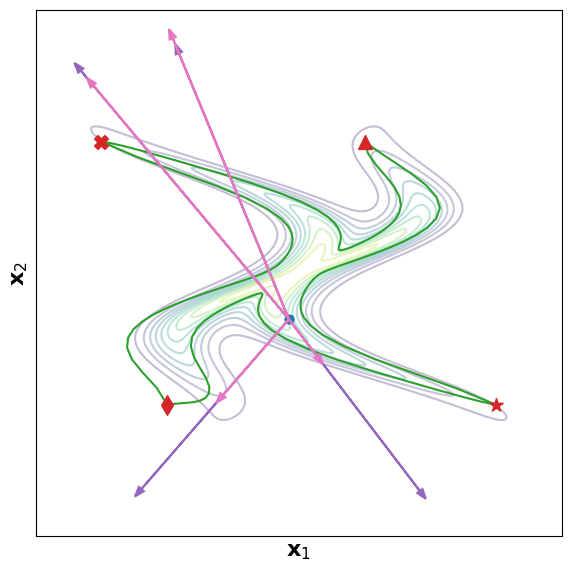

In [10]:
# special point to classify
val_data = torch.tensor([-0.15, -.7])

# compute logs from point to archetypes
with torch.no_grad():
    log_Omega = Omega_manifold.log(val_data[None,None], archetypes[None])[0,0].detach() * 0.85
    iso_log_Omega = iso_Omega_manifold.log(val_data[None,None], archetypes[None])[0,0].detach()

# plot special point
plt.figure(figsize=(6, 6))
plt.contour(X.numpy(), Y.numpy(), log_probs_multi.numpy(), levels=10, cmap='viridis', alpha=0.3, zorder=0)
for i in range(4):
    plt.plot(Omega_geodesics[i,:,0].numpy(), Omega_geodesics[i,:,1].numpy(), color=plt.cm.tab10(2), zorder=1)   
for i in range(4):  
    plt.scatter(archetypes[i, 0].numpy(), archetypes[i, 1].numpy(), color=plt.cm.tab10(3), marker=markers[i], s=100, zorder=2)
plt.scatter(val_data[0].numpy(), val_data[1].numpy(), color=plt.cm.tab10(0), marker='o', s=40, zorder=3)
# quiver for log maps
for i in range(4):
    plt.arrow(val_data[0].numpy(), val_data[1].numpy(), log_Omega[i, 0].numpy(), log_Omega[i, 1].numpy(), color=plt.cm.tab10(6), linewidth=1.5, head_width=0.1, length_includes_head=True, zorder=4)
    plt.arrow(val_data[0].numpy(), val_data[1].numpy(), iso_log_Omega[i, 0].numpy(), iso_log_Omega[i, 1].numpy(), color=plt.cm.tab10(4), linewidth=1.5, head_width=0.1, length_includes_head=True, zorder=3)
plt.xlabel(r'$\mathbf{x}_1$')
plt.ylabel(r'$\mathbf{x}_2$')
plt.xlim(-4, 4)
plt.ylim(-4, 4)
plt.xticks([])
plt.yticks([])
plt.tight_layout()
plt.savefig(os.path.join(results_folder, "log_Omega_val.png"))
plt.show()

Iteration 11 Convergence achieved with diff 9.49e-04. Stopping optimization.


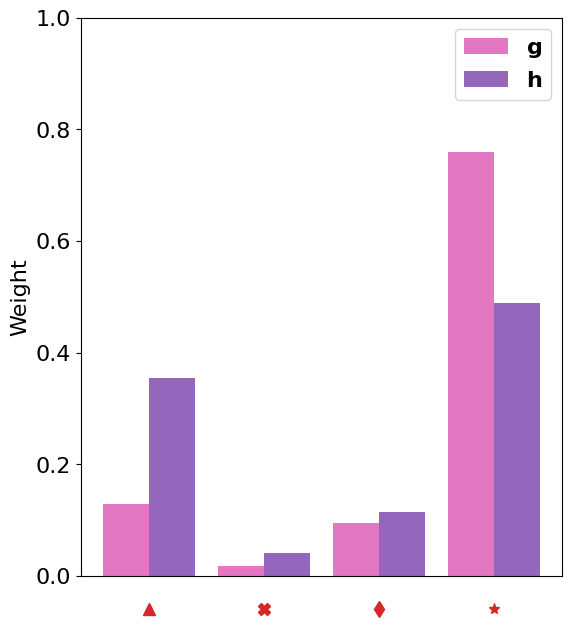

In [11]:
# find weights of special points 
with torch.no_grad():
    # compute weights for archetypes
    Omega_weights = relaxed_Omega_ram.forward(val_data[None], return_weights=True)[1][0].detach()
    # compute iso-correction factor
    iso_Omega_distances = iso_Omega_manifold.distance(val_data[None,None], archetypes[None])[0,0].detach()
    log_Omega_norm = torch.norm(log_Omega, dim=-1)
    c = log_Omega_norm / iso_Omega_distances
    # compute iso_weights
    iso_weights = c * Omega_weights
    # normalize iso_weights
    iso_weights = iso_weights / iso_weights.sum()

# plot weights histogram
fig, ax = plt.subplots(figsize=(6, 6.5))
ax.bar(torch.arange(4) - 0.2, Omega_weights.numpy(), width=0.4,
       color=plt.cm.tab10(6), label=r"$\mathbf{g}$")
ax.bar(torch.arange(4) + 0.2, iso_weights.numpy(), width=0.4,
       color=plt.cm.tab10(4), label=r"$\mathbf{h}$")
for i in range(4):
    ax.plot(i, -0.06,
            marker=markers[i],
            markersize=8,
            color=plt.cm.tab10(3),
            linestyle="None",
            transform=ax.get_xaxis_transform(),
            clip_on=False,
            zorder=10)
ax.set_ylim(0, 1)
ax.set_xticks(torch.arange(4))
ax.set_xticklabels([""] * 4)
ax.tick_params(axis="x", length=0)   # optional: hide tick marks too
ax.set_ylabel("Weight")
ax.legend()
plt.savefig(os.path.join(results_folder, "weights_comparison.png"))
plt.tight_layout()
plt.show()